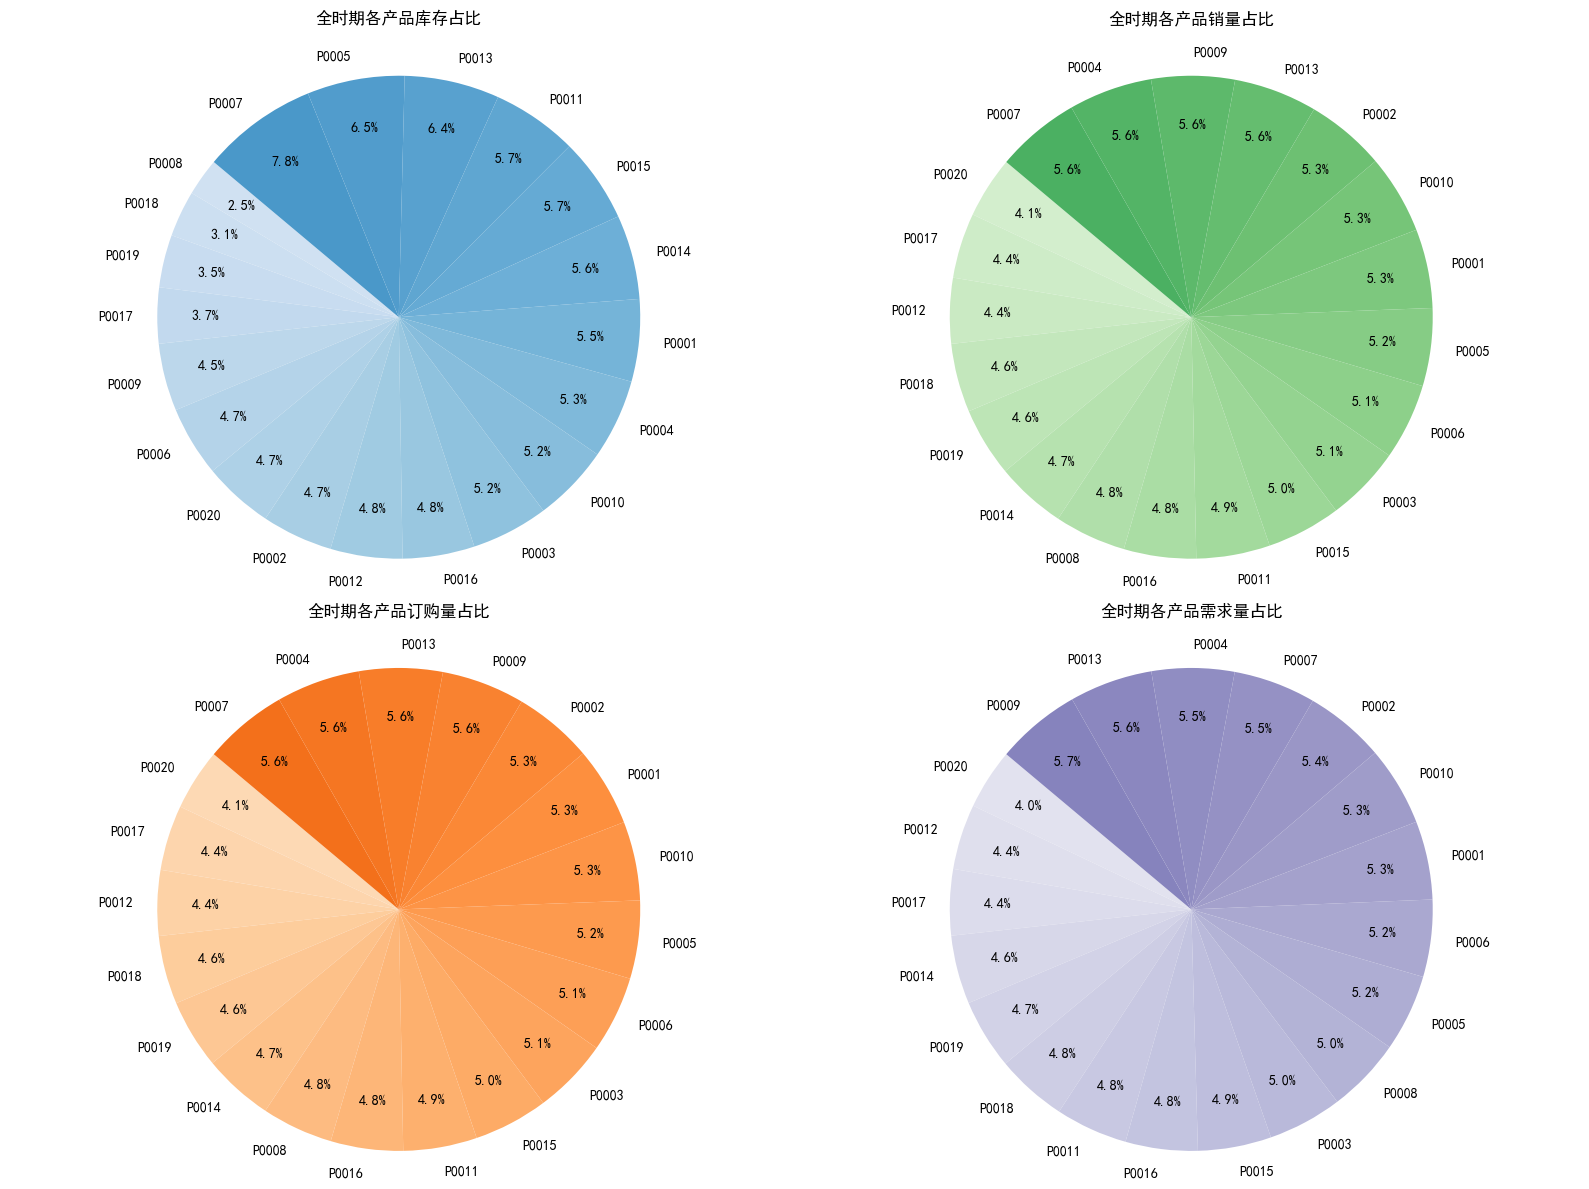

In [1]:
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv")

# 设置中文字体和负号显示
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据准备（分组求和）
inv_by_product = df.groupby("Product ID")["Inventory Level"].sum()
sales_by_product = df.groupby("Product ID")["Units Sold"].sum()
ordered_by_product = df.groupby("Product ID")["Units Ordered"].sum()
demand_by_product = df.groupby("Product ID")["Demand"].sum()

# ===== 辅助函数：根据占比排序 =====
def sort_by_ratio(series):
    ratio = series / series.sum()
    return series[ratio.sort_values().index]

# 排序后的数据
inv_sorted = sort_by_ratio(inv_by_product)
sales_sorted = sort_by_ratio(sales_by_product)
ordered_sorted = sort_by_ratio(ordered_by_product)
demand_sorted = sort_by_ratio(demand_by_product)

# 生成颜色（渐变色）
colors_inv = plt.cm.Blues(np.linspace(0.2, 0.6, len(inv_sorted)))
colors_sales = plt.cm.Greens(np.linspace(0.2, 0.6, len(sales_sorted)))
colors_ordered = plt.cm.Oranges(np.linspace(0.2, 0.6, len(ordered_sorted)))
colors_demand = plt.cm.Purples(np.linspace(0.2, 0.6, len(demand_sorted)))  # 紫色渐变

# ===== 创建子图：2行2列 =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 绘制库存饼图
axes[0, 0].pie(
    inv_sorted,
    labels=inv_sorted.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    textprops={'fontsize': 10},
    colors=colors_inv
)
axes[0, 0].set_title("全时期各产品库存占比", pad=20)
axes[0, 0].axis('equal')

# 绘制销量饼图
axes[0, 1].pie(
    sales_sorted,
    labels=sales_sorted.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    textprops={'fontsize': 10},
    colors=colors_sales
)
axes[0, 1].set_title("全时期各产品销量占比", pad=20)
axes[0, 1].axis('equal')

# 绘制订购量饼图
axes[1, 0].pie(
    ordered_sorted,
    labels=ordered_sorted.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1,
    textprops={'fontsize': 10},
    colors=colors_ordered
)
axes[1, 0].set_title("全时期各产品订购量占比", pad=20)
axes[1, 0].axis('equal')

# 绘制需求量饼图
axes[1, 1].pie(
    demand_sorted,
    labels=demand_sorted.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    textprops={'fontsize': 10},
    colors=colors_demand
)
axes[1, 1].set_title("全时期各产品需求量占比", pad=20)
axes[1, 1].axis('equal')

# 自动调整布局
plt.tight_layout()
plt.savefig("四图对比.png", dpi=90)
plt.show()
